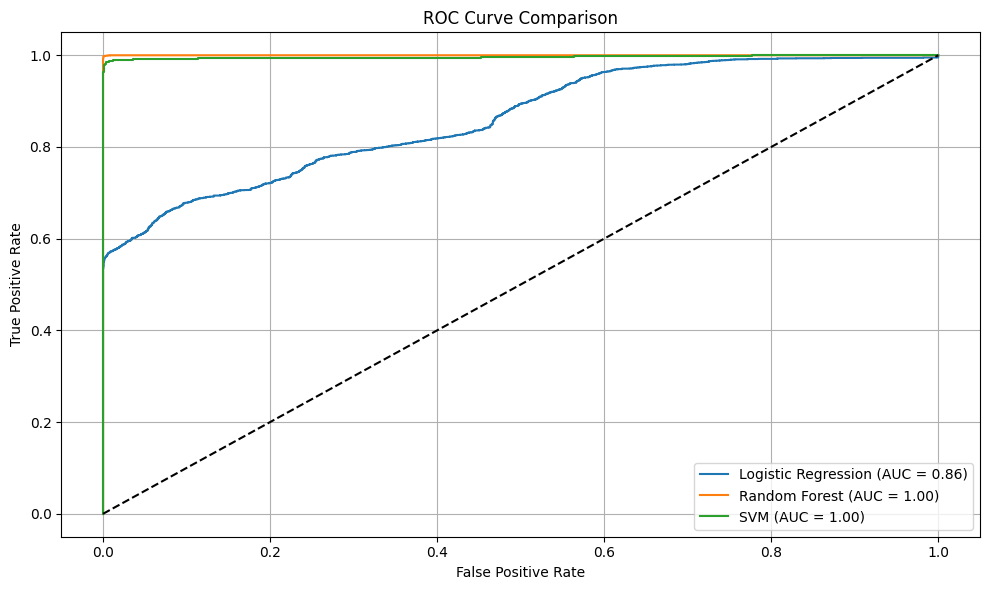


===== Logistic Regression =====
Train Accuracy: 0.7679
Test Accuracy:  0.7576

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      2550
           1       0.78      0.77      0.78      3049

    accuracy                           0.76      5599
   macro avg       0.76      0.76      0.76      5599
weighted avg       0.76      0.76      0.76      5599


===== Random Forest =====
Train Accuracy: 1.0000
Test Accuracy:  0.9979

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2550
           1       1.00      1.00      1.00      3049

    accuracy                           1.00      5599
   macro avg       1.00      1.00      1.00      5599
weighted avg       1.00      1.00      1.00      5599


===== SVM =====
Train Accuracy: 0.9774
Test Accuracy:  0.9818

Classification Report (Test):
              precision    recall  f1-

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, RocCurveDisplay
)
import pandas as pd

# Load the dataset
file_path = 'J:\\pddt\\raheebpd.csv'
df = pd.read_csv(file_path)


# Display the first few rows to understand the structure of the dataset
df.head()


# Select features and target
features = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
X = df[features]
y = df['Result']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True)
}

# Store results
results = {}

# Training and evaluation
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "conf_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }

# Plot ROC curves
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC = {res['auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import accuracy_score, classification_report

# Assuming you already have models: Logistic Regression, Random Forest, and SVM trained
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))


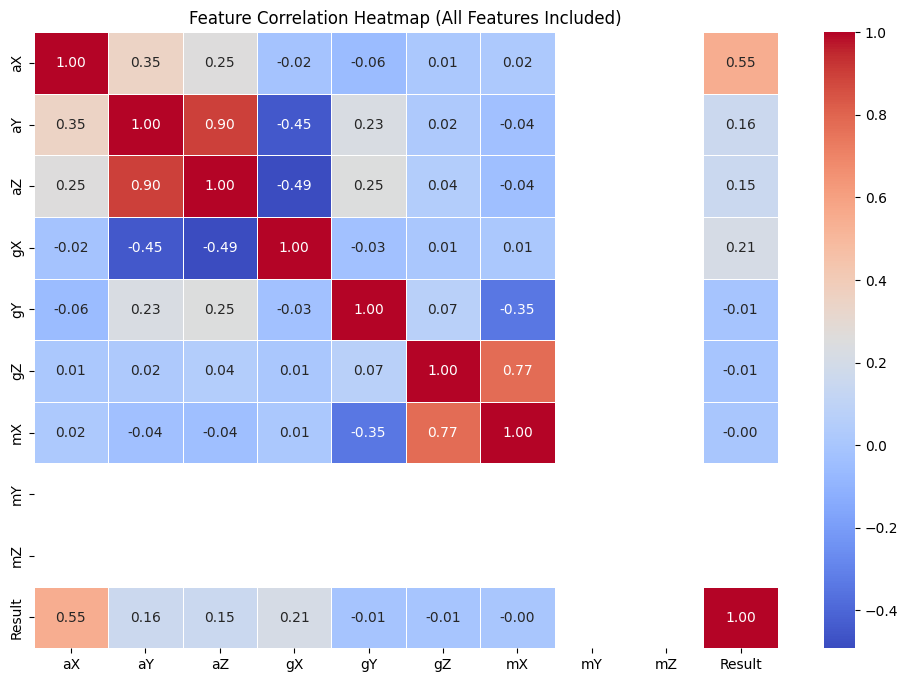

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "J:\\pddt\\raheebpd.csv"  # change path if needed
df = pd.read_csv(file_path)

# Convert all columns to numeric where possible (non-numeric become NaN)
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Compute correlation matrix using all possible numeric data
corr = df_numeric.corr()

# Plot correlation heatmap with values
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap (All Features Included)")
plt.show()



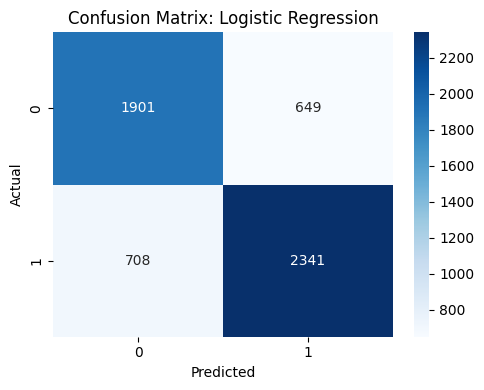

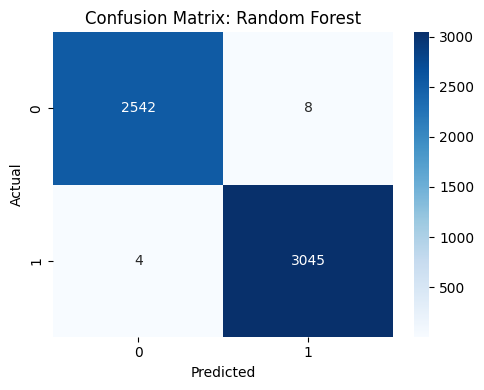

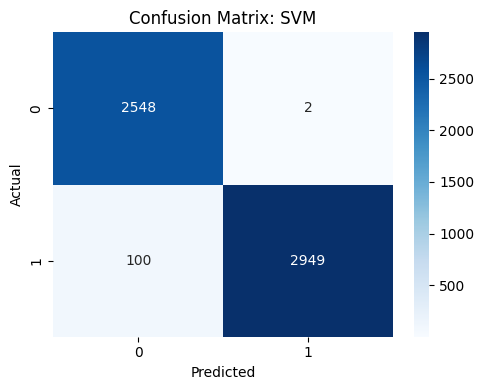

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay

# Plot confusion matrices
for name, model in models.items():
    y_test_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()



===== Logistic Regression =====
Train Accuracy: 0.7679
Test Accuracy:  0.7576
Accuracy Difference: 0.0103

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      2550
           1       0.78      0.77      0.78      3049

    accuracy                           0.76      5599
   macro avg       0.76      0.76      0.76      5599
weighted avg       0.76      0.76      0.76      5599


===== Random Forest =====
Train Accuracy: 1.0000
Test Accuracy:  0.9979
Accuracy Difference: 0.0021

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2550
           1       1.00      1.00      1.00      3049

    accuracy                           1.00      5599
   macro avg       1.00      1.00      1.00      5599
weighted avg       1.00      1.00      1.00      5599


===== SVM =====
Train Accuracy: 0.9774
Test Accuracy:  0.9818
Accuracy Diff

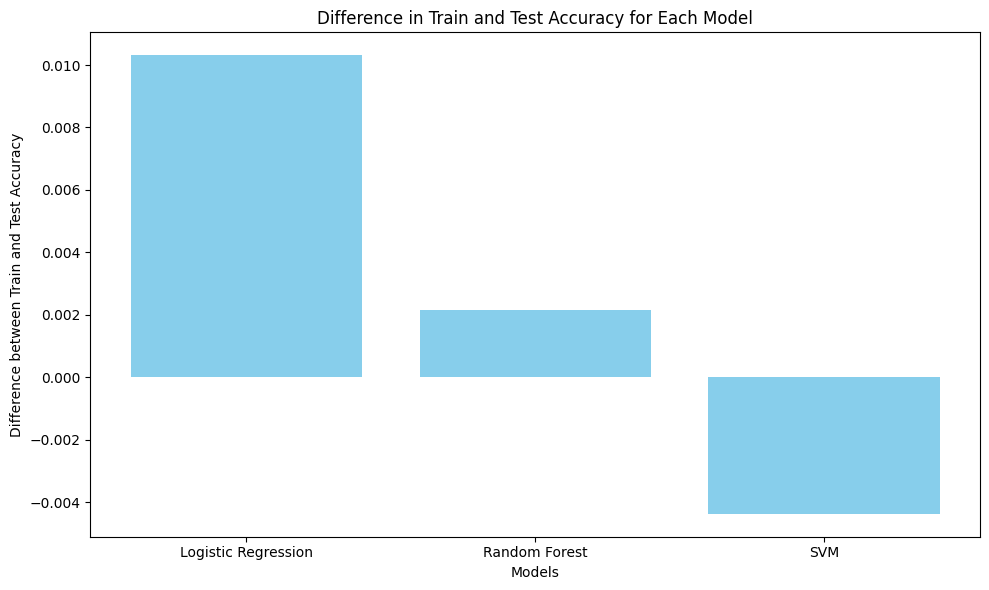

In [18]:
# Training and evaluation
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
    roc_auc = auc(fpr, tpr)

    # Calculate the difference between train and test accuracy
    accuracy_diff = train_acc - test_acc

    results[name] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "accuracy_diff": accuracy_diff,  # Store the accuracy difference
        "conf_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }



# Displaying results
from sklearn.metrics import accuracy_score, classification_report

# Display the classification results and the difference between train and test accuracy
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Accuracy Difference: {results[name]['accuracy_diff']:.4f}")  # Now this will work properly
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))

# Plotting the accuracy difference for each model
model_names = list(results.keys())
accuracy_diffs = [results[model]['accuracy_diff'] for model in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracy_diffs, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Difference between Train and Test Accuracy')
plt.title('Difference in Train and Test Accuracy for Each Model')
plt.tight_layout()

# Corrected plt.show() line
plt.show()  # Ensure the function is properly closed with a parenthesis

In [20]:
import joblib

# Assuming you have 'scaler' and 'models["SVM"]' from your training
svm_model_bundle = {
    'scaler': scaler,
    'model': models["SVM"]
}

# Save to a file
joblib.dump(svm_model_bundle, 'J:\pddt\svm_model_with_scaler.pkl')
print("Model and scaler saved to svm_model_with_scaler.pkl")


Model and scaler saved to svm_model_with_scaler.pkl
